In [1]:
pip install langchain-openai langchain-community langchain-text-splitters langchain-core langgraph python-dotenv faiss-cpu pypdf

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
pip install langchain_ollama

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
pip install langchain_huggingface

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
pip install sentence-transformers

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
import re
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_ollama import ChatOllama
from dotenv import load_dotenv
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS
from langchain_core.tools import tool
from langgraph.graph import StateGraph, START
from typing import Annotated, TypedDict
from langgraph.graph.message import add_messages
from langchain_core.messages import HumanMessage, BaseMessage
from langgraph.prebuilt import ToolNode, tools_condition
from langchain_huggingface import HuggingFaceEmbeddings

C:\Users\bjit\AppData\Local\Temp\ipykernel_24312\3607031679.py:5: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import PyPDFLoader
c:\Users\bjit\Downloads\langgraph\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [6]:
llm = ChatOllama(model = 'qwen3:0.6b', temperature=0)

In [7]:
loader = PyPDFLoader("saikat.pdf")
docs = loader.load()

In [8]:
len(docs)

2

In [9]:
splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=200)
chunks = splitter.split_documents(docs)

In [10]:
len(chunks)

2

In [11]:
embeddings = HuggingFaceEmbeddings(model_name="all-MiniLM-L6-v2")
vector_store = FAISS.from_documents(chunks, embeddings)

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 2875.24it/s]


In [12]:
vector_store

In [13]:
retriever = vector_store.as_retriever(search_type='similarity', search_kwargs={'k':4})

In [14]:
@tool
def rag_tool(query):

    """
    Retrieve relevant information from the pdf document.
    Use this tool when the user asks factual / conceptual questions
    that might be answered from the stored documents.
    """
    result = retriever.invoke(query)

    context = [doc.page_content for doc in result]
    metadata = [doc.metadata for doc in result]

    return {
        'query': query,
        'context': context,
        'metadata': metadata
    }

In [15]:
tools = [rag_tool]
llm_with_tools = llm.bind_tools(tools)

In [16]:
class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

In [17]:
def chat_node(state: ChatState):

    messages = state['messages']
    question = messages[-1].content

    result = retriever.invoke(question)
    context = "\n\n".join(doc.page_content for doc in result)

    prompt = (
        "/no_think\n"
        "Answer the question using ONLY the context below.\n"
        "If the answer is not in the context, say you don't know.\n"
        "Keep the answer short and clear.\n\n"
        f"Context:\n{context}\n\n"
        f"Question: {question}\n\n"
        "Answer:"
    )

    response = llm.invoke(prompt)
    response.content = re.sub(r"<think>.*?</think>", "", response.content, flags=re.DOTALL).strip()

    return {'messages': [response]}

In [18]:
tool_node = ToolNode(tools)

In [19]:
graph = StateGraph(ChatState)

graph.add_node('chat_node', chat_node)
graph.add_node('tools', tool_node)

graph.add_edge(START, 'chat_node')
graph.add_conditional_edges('chat_node', tools_condition)
graph.add_edge('tools', 'chat_node')

chatbot = graph.compile()

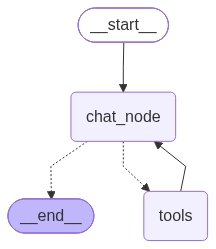

In [20]:
chatbot

In [21]:
result = chatbot.invoke(
    {
        "messages": [
            HumanMessage(
                content=(
                    "what is saikat's phone number"
                )
            )
        ]
    }
)

In [22]:
print(result['messages'][-1].content)

Answer: 01708652827
